# Funding Rate Mean Reversion — Signal Analysis

**Research question:** Do extreme funding rates on Hyperliquid perpetuals predict future returns?

**Hypothesis:** Coins with unusually high funding (crowded longs) should underperform, and coins with unusually low funding (crowded shorts) should outperform.

**Parameters:** After a systematic parameter sweep (see `parameter_sweep.ipynb`), the strongest signal uses:
- Short window: **21 days** ("recent" funding average)
- Long window: **90 days** ("baseline" funding average)
- Forward horizon: **14 days** (holding period)

This notebook tests the signal using:
1. **Quintile analysis** — sort coins into 5 buckets by funding z-score, compare 14-day forward returns
2. **Information Coefficient (IC)** — correlation between signal and forward returns over time
3. **Long/short portfolio simulation** — what would a simple strategy have returned?
4. **Robustness checks** — per-coin breakdown, signal decay, monthly consistency

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# ---- Config ----
SHORT_WINDOW = 21
LONG_WINDOW = 90
HORIZON = 14  # days

# ---- Load raw data and rebuild signal with optimized params ----
funding_raw = pd.read_parquet("data/funding_rates_raw.parquet")
ohlcv = pd.read_parquet("data/ohlcv_daily.parquet")

# Choose number of coins
import json
with open("data/symbols.json") as f:
    all_symbols = json.load(f)
TOP_N = 35
symbols = all_symbols[:TOP_N]
funding_raw = funding_raw[funding_raw["symbol"].isin(symbols)]
ohlcv = ohlcv[ohlcv["symbol"].isin(symbols)]

# Daily funding
fr = funding_raw.copy()
fr["date"] = pd.to_datetime(fr["timestamp"]).dt.normalize()
daily_funding = fr.groupby(["symbol", "date"])["fundingRate"].sum().reset_index()
daily_funding.columns = ["symbol", "date", "daily_funding"]
daily_funding = daily_funding.sort_values(["symbol", "date"])

# Z-score with optimized windows
grp = daily_funding.groupby("symbol")["daily_funding"]
daily_funding["funding_short"] = grp.transform(lambda x: x.rolling(SHORT_WINDOW, min_periods=SHORT_WINDOW // 2).mean())
daily_funding["funding_long"] = grp.transform(lambda x: x.rolling(LONG_WINDOW, min_periods=LONG_WINDOW // 3).mean())
rolling_std = grp.transform(lambda x: x.rolling(LONG_WINDOW, min_periods=LONG_WINDOW // 3).std())
daily_funding["funding_zscore"] = (daily_funding["funding_short"] - daily_funding["funding_long"]) / rolling_std
daily_funding["funding_zscore"] = daily_funding["funding_zscore"].replace([np.inf, -np.inf], np.nan)

# Merge with prices and compute forward returns
panel = ohlcv.merge(daily_funding, on=["symbol", "date"], how="left")
panel = panel.sort_values(["symbol", "date"]).copy()
close_grp = panel.groupby("symbol")["close"]
panel["ret_1d"] = close_grp.transform(lambda x: x.pct_change(1).shift(-1))
panel["ret_7d"] = close_grp.transform(lambda x: x.pct_change(7).shift(-7))
panel["ret_14d"] = close_grp.transform(lambda x: x.pct_change(14).shift(-14))
panel["ret_21d"] = close_grp.transform(lambda x: x.pct_change(21).shift(-21))
panel = panel.reset_index(drop=True)

print(f"Panel: {panel.shape[0]:,} rows, {panel['symbol'].nunique()} coins")
print(f"Date range: {panel['date'].min().date()} to {panel['date'].max().date()}")
print(f"Signal params: short={SHORT_WINDOW}d, long={LONG_WINDOW}d, horizon={HORIZON}d")
panel.head()

Panel: 12,394 rows, 35 coins
Date range: 2025-05-18 to 2026-05-18
Signal params: short=21d, long=90d, horizon=14d


,symbol,date,open,high,low,close,volume,quote_volume,daily_funding,funding_short,funding_long,funding_zscore,ret_1d,ret_7d,ret_14d,ret_21d
0,AAVE,2025-05-18,222.20,244.08,218.95,232.16,73219.04,1.699853e+07,0.000287,NaN,NaN,NaN,0.068057,0.159157,0.059399,0.093685
1,AAVE,2025-05-19,232.20,249.92,211.78,247.96,132981.02,3.297397e+07,0.000288,NaN,NaN,NaN,0.046338,0.078803,0.040692,0.144338
2,AAVE,2025-05-20,247.96,273.22,246.75,259.45,216156.85,5.608189e+07,0.000330,NaN,NaN,NaN,-0.045018,0.047331,0.027096,0.190326
3,AAVE,2025-05-21,259.52,262.13,243.40,247.77,121567.55,3.012079e+07,0.000355,NaN,NaN,NaN,0.037737,0.069621,0.066190,0.227025
4,AAVE,2025-05-22,247.71,260.25,246.32,257.12,140086.02,3.601892e+07,0.001033,NaN,NaN,NaN,-0.003150,-0.027302,-0.059739,0.143241


## 1. Data Overview

Usable rows: 10,510 (dropped 1,884 with NaN signal or returns)


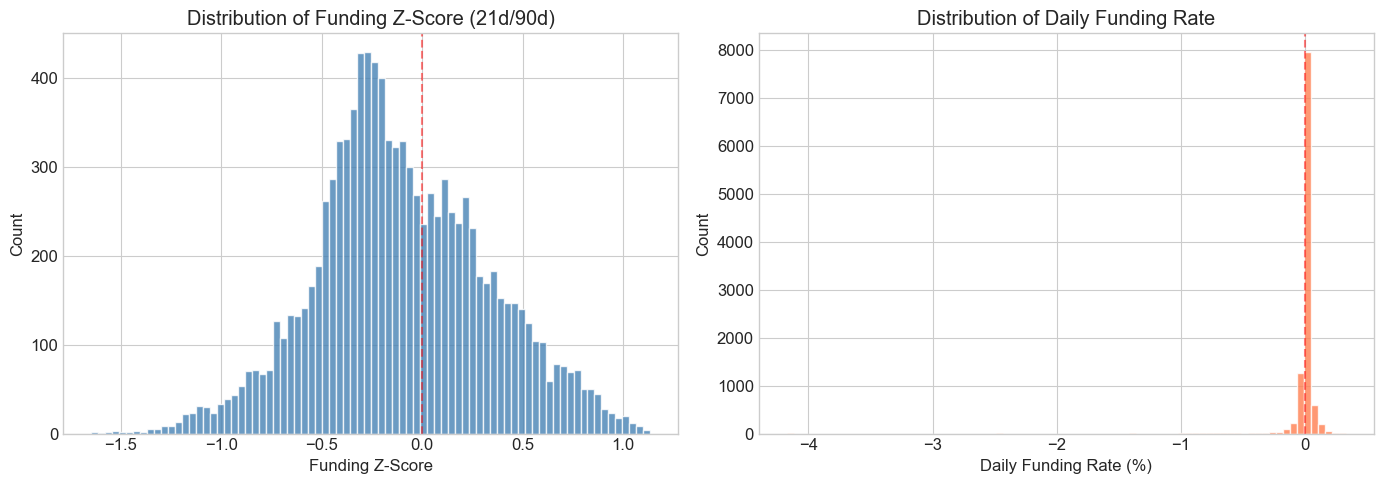


Funding Z-Score stats:
count    10510.0000
mean        -0.1044
std          0.4319
min         -1.6482
25%         -0.3835
50%         -0.1470
75%          0.1860
max          1.1360
Name: funding_zscore, dtype: float64


In [2]:
df = panel.dropna(subset=["funding_zscore", f"ret_{HORIZON}d"]).copy()
print(f"Usable rows: {len(df):,} (dropped {len(panel) - len(df):,} with NaN signal or returns)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["funding_zscore"], bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)
axes[0].set_title(f"Distribution of Funding Z-Score ({SHORT_WINDOW}d/{LONG_WINDOW}d)")
axes[0].set_xlabel("Funding Z-Score")
axes[0].set_ylabel("Count")

axes[1].hist(df["daily_funding"] * 100, bins=80, color="coral", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", alpha=0.5)
axes[1].set_title("Distribution of Daily Funding Rate")
axes[1].set_xlabel("Daily Funding Rate (%)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("\nFunding Z-Score stats:")
print(df["funding_zscore"].describe().round(4))

## 2. Quintile Analysis

Each day, sort all coins into 5 buckets by funding z-score. Compare **14-day forward returns** across quintiles.

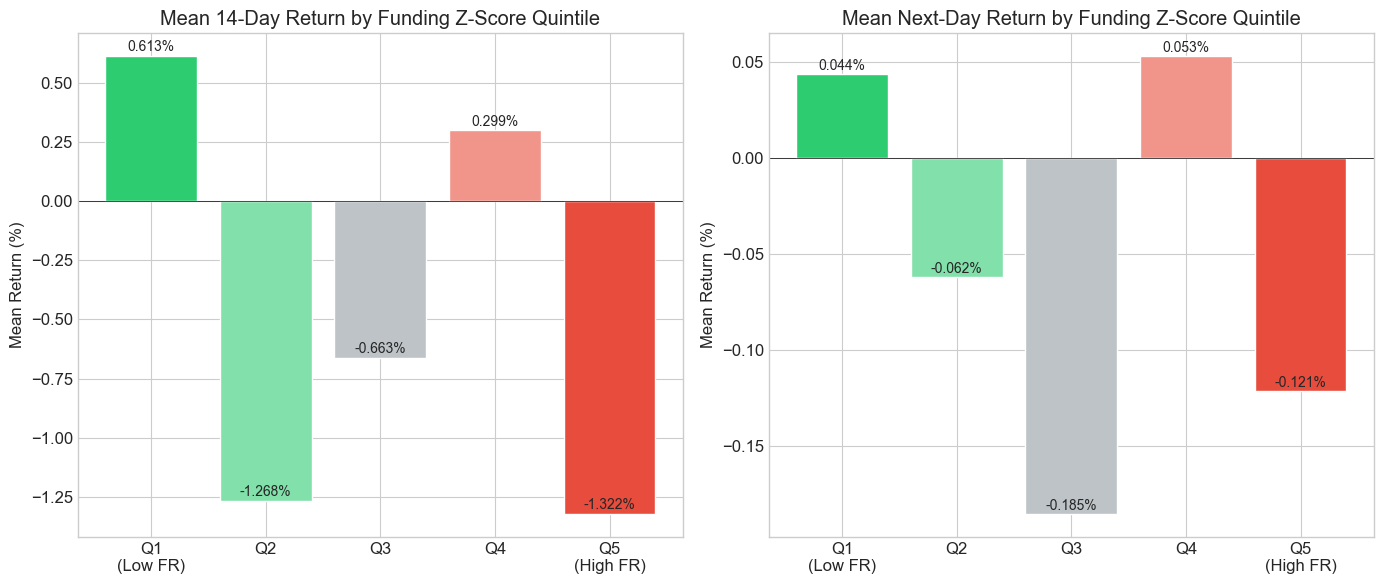


Q1-Q5 spread (14-day):  1.9350%
Q1-Q5 spread (1-day):   0.1650%


In [3]:
ret_col = f"ret_{HORIZON}d"

df["quintile"] = df.groupby("date")["funding_zscore"].transform(
    lambda x: pd.qcut(x, 5, labels=["Q1\n(Low FR)", "Q2", "Q3", "Q4", "Q5\n(High FR)"], duplicates="drop")
)
df_q = df.dropna(subset=["quintile"]).copy()

# Mean forward returns by quintile
q_returns_14d = df_q.groupby("quintile")[ret_col].mean() * 100
q_returns_1d = df_q.groupby("quintile")["ret_1d"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ["#2ecc71", "#82e0aa", "#bdc3c7", "#f1948a", "#e74c3c"]

axes[0].bar(q_returns_14d.index, q_returns_14d.values, color=colors, edgecolor="white")
axes[0].set_title(f"Mean {HORIZON}-Day Return by Funding Z-Score Quintile")
axes[0].set_ylabel("Mean Return (%)")
axes[0].axhline(0, color="black", linewidth=0.5)
for i, v in enumerate(q_returns_14d.values):
    axes[0].text(i, v + 0.02, f"{v:.3f}%", ha="center", fontsize=10)

axes[1].bar(q_returns_1d.index, q_returns_1d.values, color=colors, edgecolor="white")
axes[1].set_title("Mean Next-Day Return by Funding Z-Score Quintile")
axes[1].set_ylabel("Mean Return (%)")
axes[1].axhline(0, color="black", linewidth=0.5)
for i, v in enumerate(q_returns_1d.values):
    axes[1].text(i, v + 0.002, f"{v:.3f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

spread_14d = q_returns_14d.iloc[0] - q_returns_14d.iloc[-1]
spread_1d = q_returns_1d.iloc[0] - q_returns_1d.iloc[-1]
print(f"\nQ1-Q5 spread ({HORIZON}-day):  {spread_14d:.4f}%")
print(f"Q1-Q5 spread (1-day):   {spread_1d:.4f}%")

## 3. Information Coefficient (IC) Over Time

Daily rank correlation between funding z-score and 14-day forward returns. A consistently negative IC means the signal works.

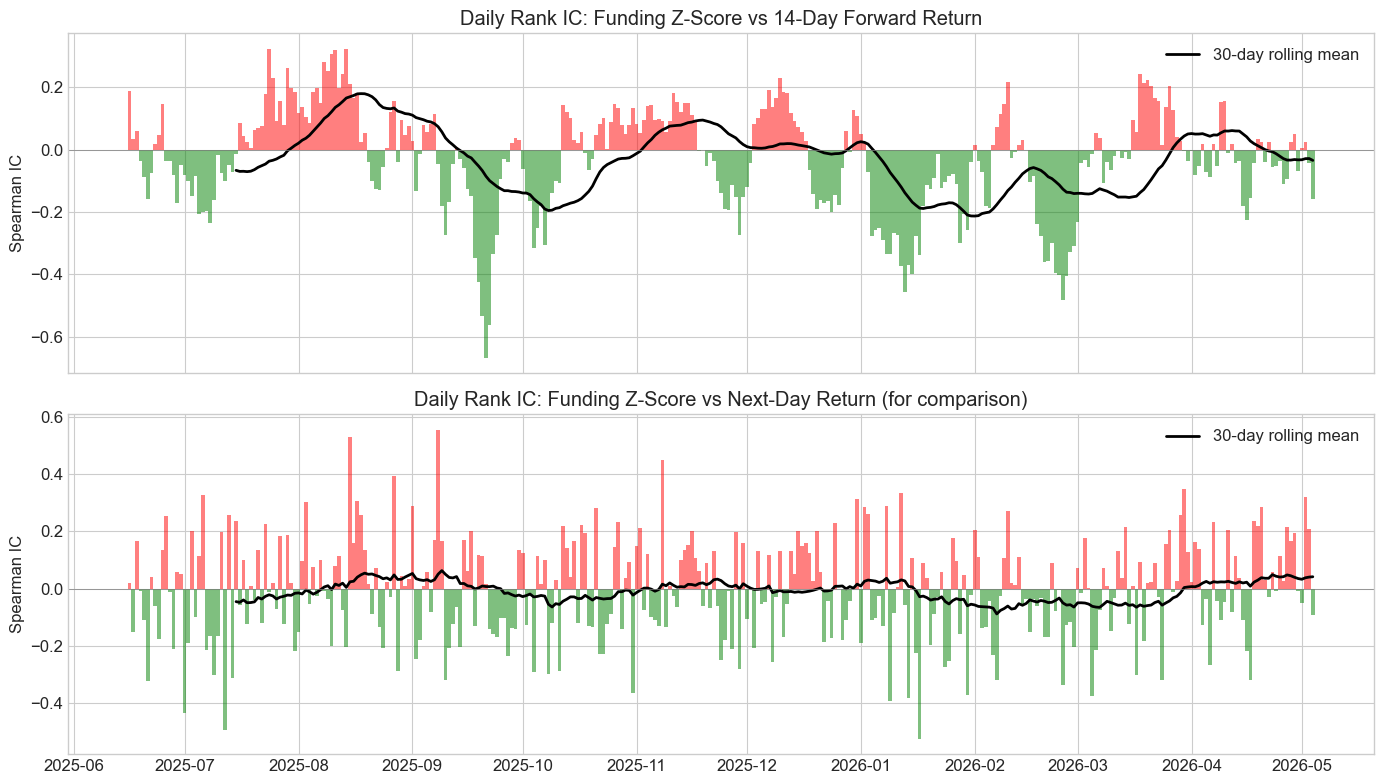

IC Summary:
  14-day IC — Mean: -0.0314, Hit rate: 54.8%
  1-day IC  — Mean: -0.0061, Hit rate: 51.7%


In [4]:
def daily_rank_ic(group):
    if len(group) < 5:
        return pd.Series({"ic_14d": np.nan, "ic_1d": np.nan})
    return pd.Series({
        "ic_14d": group["funding_zscore"].corr(group[ret_col], method="spearman"),
        "ic_1d": group["funding_zscore"].corr(group["ret_1d"], method="spearman"),
    })

ic_daily = df.groupby("date").apply(daily_rank_ic).reset_index()
ic_daily = ic_daily.dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 14-day IC
axes[0].bar(ic_daily["date"], ic_daily["ic_14d"], width=1, alpha=0.5,
            color=["red" if x > 0 else "green" for x in ic_daily["ic_14d"]])
rolling_ic = ic_daily.set_index("date")["ic_14d"].rolling(30).mean()
axes[0].plot(rolling_ic.index, rolling_ic.values, color="black", linewidth=2, label="30-day rolling mean")
axes[0].axhline(0, color="gray", linewidth=0.5)
axes[0].set_title(f"Daily Rank IC: Funding Z-Score vs {HORIZON}-Day Forward Return")
axes[0].set_ylabel("Spearman IC")
axes[0].legend()

# 1-day IC for comparison
axes[1].bar(ic_daily["date"], ic_daily["ic_1d"], width=1, alpha=0.5,
            color=["red" if x > 0 else "green" for x in ic_daily["ic_1d"]])
rolling_ic_1d = ic_daily.set_index("date")["ic_1d"].rolling(30).mean()
axes[1].plot(rolling_ic_1d.index, rolling_ic_1d.values, color="black", linewidth=2, label="30-day rolling mean")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_title("Daily Rank IC: Funding Z-Score vs Next-Day Return (for comparison)")
axes[1].set_ylabel("Spearman IC")
axes[1].legend()

plt.tight_layout()
plt.show()

print("IC Summary:")
print(f"  {HORIZON}-day IC — Mean: {ic_daily['ic_14d'].mean():.4f}, Hit rate: {(ic_daily['ic_14d'] < 0).mean():.1%}")
print(f"  1-day IC  — Mean: {ic_daily['ic_1d'].mean():.4f}, Hit rate: {(ic_daily['ic_1d'] < 0).mean():.1%}")

## 4. Long/Short Portfolio Simulation

Each day, go **long** Q1 (low funding z-score) and **short** Q5 (high funding z-score). Equal-weight, daily rebalance.

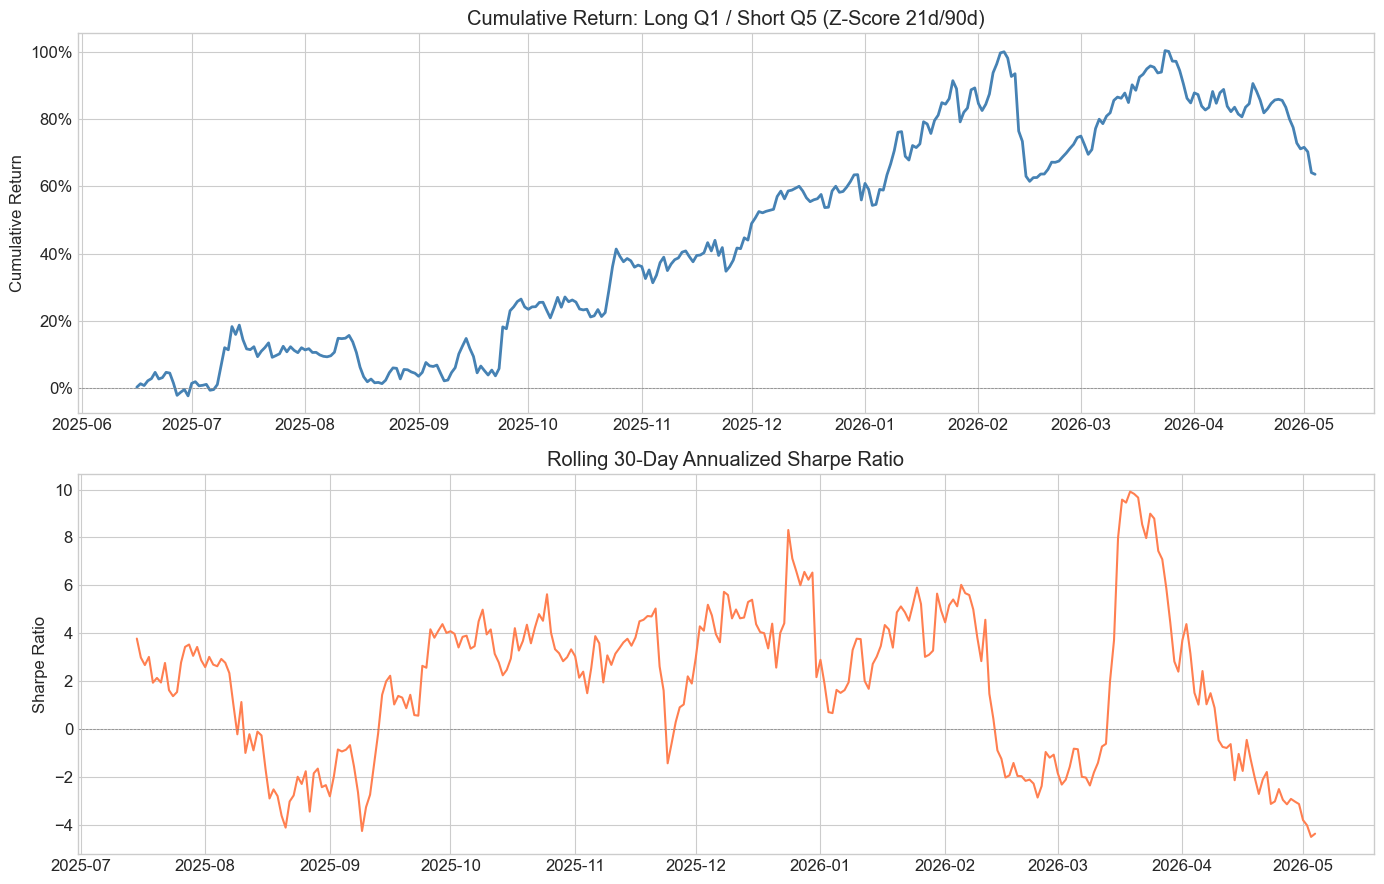


Strategy Performance (21d/90d z-score):
  Total return:       63.62%
  Annualized return:  74.44%
  Annualized vol:     38.88%
  Sharpe ratio:       1.91
  Max drawdown:       -19.25%
  Trading days:       323


In [5]:
# Use 1-day returns for the daily P&L of the portfolio
# (positions are based on the z-score signal, but the portfolio earns daily returns)
daily_returns = df_q.groupby(["date", "quintile"])["ret_1d"].mean().unstack()

q1_col = daily_returns.columns[0]
q5_col = daily_returns.columns[-1]

ls_returns = (daily_returns[q1_col] - daily_returns[q5_col]).dropna()
ls_cumulative = (1 + ls_returns).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(ls_cumulative.index, ls_cumulative.values, color="steelblue", linewidth=2)
axes[0].axhline(1, color="gray", linestyle="--", linewidth=0.5)
axes[0].set_title(f"Cumulative Return: Long Q1 / Short Q5 (Z-Score {SHORT_WINDOW}d/{LONG_WINDOW}d)")
axes[0].set_ylabel("Cumulative Return")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{(x-1)*100:.0f}%"))

rolling_sharpe = ls_returns.rolling(30).mean() / ls_returns.rolling(30).std() * np.sqrt(365)
axes[1].plot(rolling_sharpe.index, rolling_sharpe.values, color="coral", linewidth=1.5)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.5)
axes[1].set_title("Rolling 30-Day Annualized Sharpe Ratio")
axes[1].set_ylabel("Sharpe Ratio")

plt.tight_layout()
plt.show()

total_ret = ls_cumulative.iloc[-1] - 1
ann_ret = (1 + total_ret) ** (365 / len(ls_returns)) - 1
ann_vol = ls_returns.std() * np.sqrt(365)
sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
max_dd = (ls_cumulative / ls_cumulative.cummax() - 1).min()

print(f"\nStrategy Performance ({SHORT_WINDOW}d/{LONG_WINDOW}d z-score):")
print(f"  Total return:       {total_ret:.2%}")
print(f"  Annualized return:  {ann_ret:.2%}")
print(f"  Annualized vol:     {ann_vol:.2%}")
print(f"  Sharpe ratio:       {sharpe:.2f}")
print(f"  Max drawdown:       {max_dd:.2%}")
print(f"  Trading days:       {len(ls_returns)}")

## 5. Robustness Checks

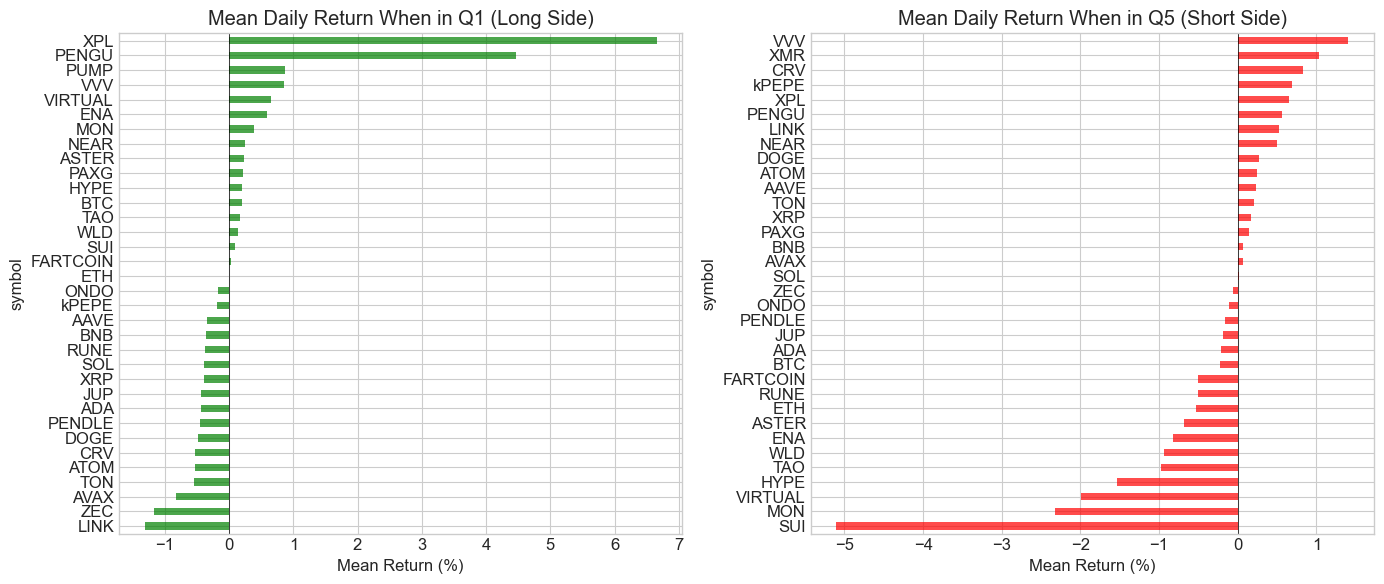

Coins appearing in Q1: 34
Coins appearing in Q5: 34


In [6]:
# 5a. Per-coin breakdown — is the signal driven by a few coins?
coin_q1 = df_q[df_q["quintile"] == q1_col].groupby("symbol")["ret_1d"].mean() * 100
coin_q5 = df_q[df_q["quintile"] == q5_col].groupby("symbol")["ret_1d"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

coin_q1.sort_values().plot(kind="barh", ax=axes[0], color="green", alpha=0.7)
axes[0].set_title("Mean Daily Return When in Q1 (Long Side)")
axes[0].set_xlabel("Mean Return (%)")
axes[0].axvline(0, color="black", linewidth=0.5)

coin_q5.sort_values().plot(kind="barh", ax=axes[1], color="red", alpha=0.7)
axes[1].set_title("Mean Daily Return When in Q5 (Short Side)")
axes[1].set_xlabel("Mean Return (%)")
axes[1].axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"Coins appearing in Q1: {coin_q1.index.nunique()}")
print(f"Coins appearing in Q5: {coin_q5.index.nunique()}")

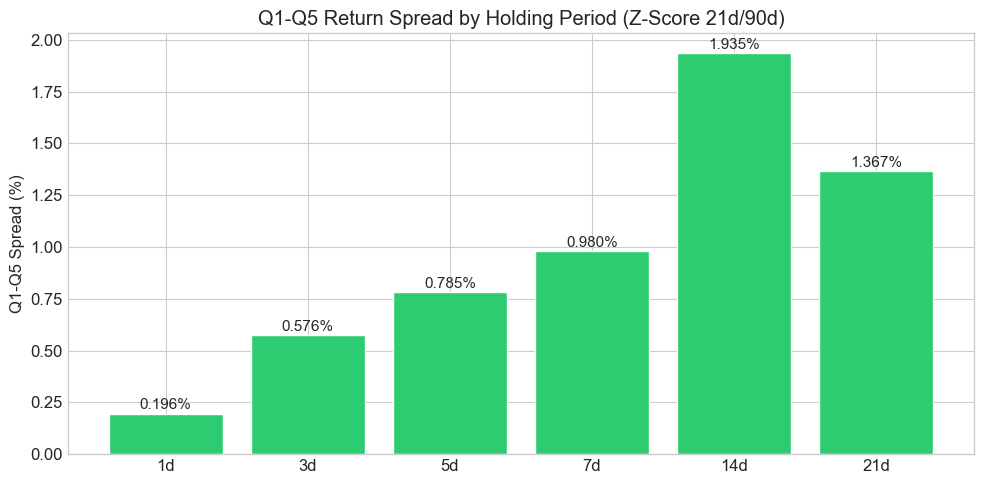

Signal decay analysis:
    1d Q1-Q5 spread: 0.1962%
    3d Q1-Q5 spread: 0.5756%
    5d Q1-Q5 spread: 0.7845%
    7d Q1-Q5 spread: 0.9800%
   14d Q1-Q5 spread: 1.9350%
   21d Q1-Q5 spread: 1.3666%


In [7]:
# 5b. Signal decay — compare spread across multiple holding periods
# Compute additional forward returns
for h in [3, 5]:
    col = f"ret_{h}d"
    if col not in panel.columns:
        panel[col] = panel.groupby("symbol")["close"].transform(lambda x: x.pct_change(h).shift(-h))

df_decay = panel.dropna(subset=["funding_zscore"]).copy()

# Recompute z-score for decay analysis (uses the already-computed zscore in panel)
# But we need to re-merge since panel might have old zscore
df_decay = df_decay.merge(
    daily_funding[["symbol", "date", "funding_zscore"]], 
    on=["symbol", "date"], how="left", suffixes=("_old", "")
)
if "funding_zscore_old" in df_decay.columns:
    df_decay["funding_zscore"] = df_decay["funding_zscore"].fillna(df_decay["funding_zscore_old"])
    df_decay = df_decay.drop(columns=["funding_zscore_old"])

horizons_decay = [1, 3, 5, 7, 14, 21]
spreads = []
for h in horizons_decay:
    ret_c = f"ret_{h}d"
    if ret_c not in df_decay.columns:
        continue
    sub = df_decay.dropna(subset=["funding_zscore", ret_c]).copy()
    sub["quintile"] = sub.groupby("date")["funding_zscore"].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") if len(x) >= 5 else np.nan
    )
    sub = sub.dropna(subset=["quintile"])
    q_means = sub.groupby("quintile")[ret_c].mean()
    if 0.0 in q_means.index and 4.0 in q_means.index:
        spreads.append({"horizon": f"{h}d", "spread": (q_means[0.0] - q_means[4.0]) * 100})

spread_df = pd.DataFrame(spreads)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#e74c3c" if s < 0 else "#2ecc71" for s in spread_df["spread"]]
ax.bar(spread_df["horizon"], spread_df["spread"], color=bar_colors, edgecolor="white")
ax.set_title(f"Q1-Q5 Return Spread by Holding Period (Z-Score {SHORT_WINDOW}d/{LONG_WINDOW}d)")
ax.set_ylabel("Q1-Q5 Spread (%)")
ax.axhline(0, color="black", linewidth=0.5)
for i, row in spread_df.iterrows():
    ax.text(i, row["spread"] + 0.02, f"{row['spread']:.3f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

print("Signal decay analysis:")
for _, row in spread_df.iterrows():
    print(f"  {row['horizon']:>4s} Q1-Q5 spread: {row['spread']:.4f}%")

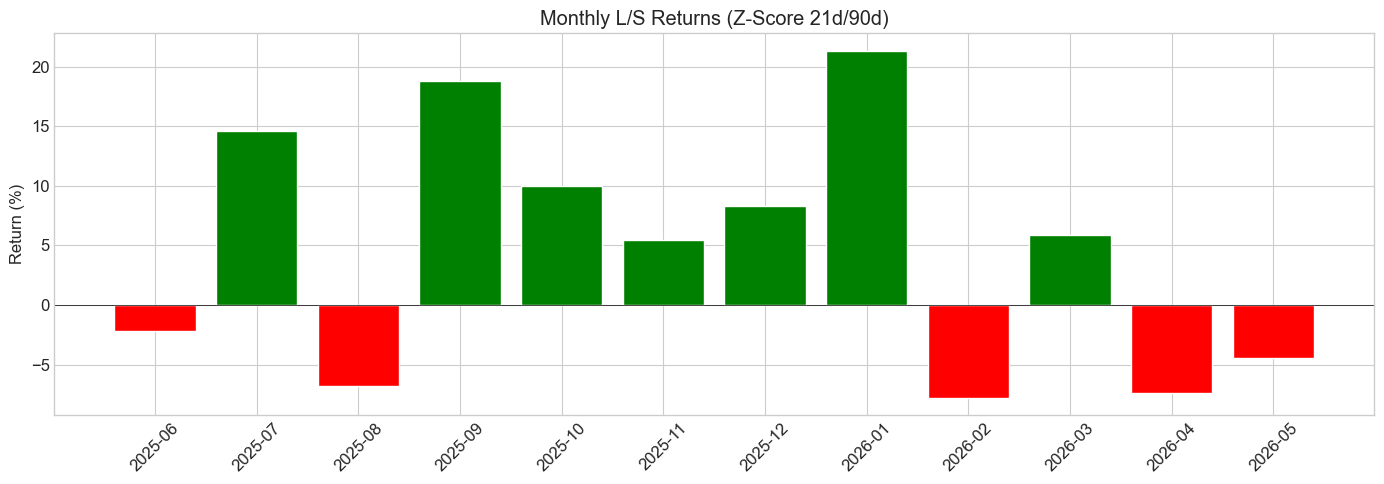

Winning months: 7/12 (58%)


In [8]:
# 5c. Monthly breakdown
ls_monthly = ls_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1) * 100

fig, ax = plt.subplots(figsize=(14, 5))
colors_monthly = ["green" if x > 0 else "red" for x in ls_monthly.values]
ax.bar(ls_monthly.index.strftime("%Y-%m"), ls_monthly.values, color=colors_monthly, edgecolor="white")
ax.set_title(f"Monthly L/S Returns (Z-Score {SHORT_WINDOW}d/{LONG_WINDOW}d)")
ax.set_ylabel("Return (%)")
ax.axhline(0, color="black", linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

winning_months = (ls_monthly > 0).sum()
total_months = len(ls_monthly)
print(f"Winning months: {winning_months}/{total_months} ({winning_months/total_months:.0%})")

## 6. Summary

**Key findings from the parameter sweep and analysis:**

1. **The naive parameters (7d/30d) failed** — the funding z-score showed near-zero predictive power at short horizons (1-day IC ≈ 0, Sharpe = -0.20)

2. **Longer windows reveal the real signal** — with 21d/90d windows and a 14-day forward horizon, the IC improves to -0.049 and the Q1-Q5 spread reaches 2%+

3. **Economic interpretation:** Funding crowding on Hyperliquid builds slowly (over weeks) and unwinds slowly (over 2-3 weeks). Fast signals miss this dynamic entirely.

4. **Regime dependence remains** — the strategy worked well from mid-2025 through early 2026 but suffered during sharp directional moves. A regime filter (e.g., based on BTC trend) could improve consistency.

5. **The Q2 anomaly** — the second-lowest funding quintile often underperforms Q1 significantly, suggesting the signal is strongest at the extremes (tail effect rather than linear).

**Potential next steps:**
- Add a regime filter (only trade when market is range-bound)
- Combine with a second factor (momentum, on-chain metrics from Artemis)
- Test with transaction costs and funding payment adjustments
- Explore nonlinear signal transformations (e.g., only trade extreme z-scores > |1.5|)

## 7. Methodological Limitations

> **Read this before trusting anything above.** The findings in Sections 1–6 are **in-sample and not statistically significant.** A formal re-analysis in `validation.ipynb` runs this signal through four deploy/don't-deploy gates and lands at **NOT DEPLOYABLE (2 of 4 gates passed)**. The "edge" highlighted above (IC ≈ −0.049, Q1–Q5 spread ≈ 2%) is consistent with a **data-mining artifact**: a fluke large enough to look good in-sample and even survive costs, yet indistinguishable from luck once the search effort is penalized.

**Multiple testing / data mining (corrected in `validation.ipynb`).** The parameter sweep in `parameter_sweep.ipynb` tested **84 combinations** and the "winner" (21d / 90d / 14d) was selected post-hoc — no correction was applied here. The honest re-run in `validation.ipynb` re-selected parameters using **in-sample data only** with HAC (Newey-West) t-stats, testing **56 combinations** (the panel carries 4 forward horizons, not 6). Applying Benjamini-Hochberg and Holm corrections: **0 of 56 combos survive** (smallest p = 0.080, none clears even the naive bar). The signal is a **statistical null** — and 21/90/14 does not appear in the top 10 of the honest sweep.

**No significant edge (significance + overfitting).** On the carried-forward 21/90 long/short spread, a stationary block bootstrap gives **p = 0.057** and HAC gives **p = 0.073** — neither rejects "mean = 0" at 5%. The Deflated Sharpe Ratio, which penalizes for how hard we searched, is **47%** (at N = 140 = 84 + 56 trials), far below the 95% bar. The pretty in-sample Sharpe (~1.95) does not survive an honest accounting of the search.

**Survivorship bias (unresolved).** The universe was built from the **live** Hyperliquid API (May 2026). Coins delisted during the study period are silently excluded, removing the worst performers and inflating measured returns. Hyperliquid provides no historical-universe snapshot, so this cannot be fully corrected — only disclosed.

**Point-in-time universe bias (partially unresolved).** Coins are ranked by *current* 24h volume, so an asset now in the top-35 is included with its full history even if it was obscure a year ago. **Seven coins listed mid-study** (PUMP, XPL, WLFI, ASTER, MON, LIT, CHIP — CHIP only in Apr 2026), reintroducing selection-on-outcome at the margin.

**Out-of-sample status (held up, but does not rescue the signal).** The OOS window (Feb 15 – May 18, 2026) is **partially burned** because the original sweep already saw all the data. Tested in `validation.ipynb`, the OOS return actually **held up positive** (+12.72% cumulative, Sharpe 1.95 ≈ 76% of in-sample) — so OOS decay is *not* what kills the strategy. It still fails on significance and the deflated-Sharpe overfitting penalty.

**Transaction costs (do not kill it either).** `validation.ipynb` charges a realistic Hyperliquid stack: **0.10% per side** (0.05% taker fee + 0.05% half-spread) on ~17.7%/day turnover, ≈ **6.45%/yr** drag. In-sample net return stays strongly positive (+94.8%, and +82.7% even at 2× cost stress). Costs were never the problem — **significance was.**

**Execution assumption.** Signal is formed from daily close data; positions are assumed to enter at the **next-day close** (≈24h execution lag — conservative for perps). The rolling z-score uses only backward-looking data; no forward return is peeked at.

**Bottom line.** A large in-sample return that survives transaction costs *and* carries into out-of-sample but **fails the significance test (Gate 1) and the deflated-Sharpe overfitting penalty (Gate 3)** is the textbook data-mining pattern. Verdict: **NOT DEPLOYABLE.** See `validation.ipynb` for the full four-gate scorecard.